# **GenAI Sprint Lab Notebook**

*(beginners → intermediate)*

**Duration:** 7 Days

**Learning Goal**

By the end of the week trainees should be able to:

- Choose the right model

- Write effective prompts

- Build GenAI apps using free APIs

- Understand image generation & GAN concepts

- Deliver a working mini project


> *Focus on understanding, not just coding*

---



| Day   | Topic                         | Outcome                      |
| ----- | ----------------------------- | ---------------------------- |
| Day 1 | Setup + GENAI Basics            | Run first GenAI model        |
| Day 2 | Tokenization & Prompts        | Understand LLM inputs        |
| Day 3 | Working with LLMs             | Summarization + Chat         |
| Day 4 | RAG Fundamentals              | Retrieval system             |
| Day 5 | Build Mini RAG App            | Ask questions from documents |
| Day 6 | GAN Fundamentals +Augmentation             | Generate images              |
| Day 7 | Final Mini Project | Complete project             |


## Section 0: Foundation + Setup  (Day 1)

📝 Get API key from: https://makersuite.google.com/app

### GENAI Foundations + Model Landscape

**Topics**
- What is Generative AI?

- Types of GenAI models

- LLM vs Diffusion vs GAN

- API-based vs local models

- Free model ecosystem

- Model Comparison

| Model Family | Cost | Speed | Strengths | Best Use Cases |
| --- | --- | --- | --- | --- |
| OpenAI (conceptual) | Usually paid | Fast | Strong reasoning, coding, tool use | Production copilots, structured assistants |
| Google Gemini | Free tier available | Fast | Good multimodal support, easy API access | Learning labs, summaries, chatbots |
| Meta Llama | Free/open weights | Medium | Local deployment, customization | Offline apps, research, fine-tuning |
| Mistral models | Free and paid options | Fast | Efficient models with strong quality for size | Lightweight assistants, low-cost apps |
| Hugging Face open models | Mostly free/open | Varies by model | Huge ecosystem and local flexibility | Experiments, demos, custom pipelines |

**Default model for this week:** `Gemini 1.5 Flash`

It is a strong default because it has a free tier, responds quickly, and is simple for beginners to use through an API while still being capable enough for prompting, summarization, chat, and RAG demos.

**📝 Task:**

Install required libraries

Add API keys

Test LLM connection

In [1]:
# Install Libraries
!pip install -q google-genai transformers sentence-transformers faiss-cpu torch torchvision matplotlib ipywidgets

In [1]:
# Gemini Setup (FREE LLM)
import os
import time
from getpass import getpass

from google import genai
from transformers import pipeline

api_key = os.getenv("GEMINI_API_KEY")
if not api_key:
    api_key = getpass("Enter your Gemini API key: ")

client = genai.Client(api_key=api_key)
GEMINI_MODELS = ["gemini-2.5-flash", "gemini-2.5-flash-lite"]
GEMINI_MODEL = GEMINI_MODELS[0]
LOCAL_TEXT_MODEL = "distilgpt2"
local_generator = None

def local_generate(prompt):
    global local_generator
    if local_generator is None:
        local_generator = pipeline("text-generation", model=LOCAL_TEXT_MODEL)
    result = local_generator(prompt, max_length=min(len(prompt.split()) + 60, 180), num_return_sequences=1, truncation=True)
    return result[0]["generated_text"]

def gemini_generate(prompt):
    global GEMINI_MODEL
    last_error = None
    for model_name in GEMINI_MODELS:
        for attempt in range(3):
            try:
                response = client.models.generate_content(
                    model=model_name,
                    contents=prompt,
                )
                GEMINI_MODEL = model_name
                return response.text
            except Exception as exc:
                last_error = exc
                error_text = str(exc)
                if "503" in error_text or "UNAVAILABLE" in error_text or "high demand" in error_text.lower():
                    time.sleep(2 * (attempt + 1))
                    continue
                if "429" in error_text or "RESOURCE_EXHAUSTED" in error_text or "quota" in error_text.lower():
                    print("Gemini quota reached. Switching to local Hugging Face fallback.")
                    return local_generate(prompt)
                raise
    if last_error is not None and ("429" in str(last_error) or "RESOURCE_EXHAUSTED" in str(last_error) or "quota" in str(last_error).lower()):
        print("Gemini quota reached. Switching to local Hugging Face fallback.")
        return local_generate(prompt)
    raise RuntimeError(f"Gemini request failed after retries on all fallback models. Last error: {last_error}")

print("Testing Gemini connection...")
print(gemini_generate("Say hello in one short sentence."))
print(f"Active primary model: {GEMINI_MODEL}")

Testing Gemini connection...
Hello there!
Active primary model: gemini-2.5-flash


In [2]:
print(gemini_generate("Explain AI simply"))

Imagine AI as teaching computers to be **smart like humans.**

Instead of just following rigid instructions, we give computers the ability to:

1.  **Learn:** By looking at tons of examples (data), they find patterns, just like we learn from experience.
2.  **Think/Understand:** They can understand language, recognize faces, or figure out strategies in a game.
3.  **Solve Problems:** They use what they've learned to make decisions, predict things, or complete tasks.

**Think of it this way:**

*   When you ask Siri or Alexa a question, AI helps it understand your voice and give a relevant answer.
*   When Netflix suggests a movie you might like, AI is predicting your preferences based on what you've watched before.
*   When a self-driving car navigates traffic, AI is processing what it "sees" and making decisions in real-time.

**In short:** AI is about making computers intelligent enough to perform tasks that typically require human brains, making our lives easier, more efficient, and

**📝 Reflection:**

- The API works when the key is valid and billing or free-tier access is enabled.
- A common error is using an invalid key or an older model name.
- Another common issue is forgetting to set the API key in the environment before running the cell.

### Prompt Engineering

**Topics**

- Anatomy of a prompt

- System vs user instructions

- Zero-shot / Few-shot prompting

- Role prompting

- Chain-of-thought prompting

- Output formatting


**Tasks**

- Improve a bad prompt → good prompt

- Create Prompt experiment log (same task, 3 prompts)

- Code Sections:

      Prompt
      Model used
      Output
      Improvement notes         


In [3]:
# Prompt Engineering Experiment Log
task = "Write a short motivational message for students learning Python."

prompts = {
    "bad_prompt": task,
    "good_prompt": "You are a supportive Python mentor. Write a warm 3-sentence motivational message for beginners learning Python.",
    "few_shot_prompt": "Example 1: Keep practicing Python every day because small steps build real skill.\nExample 2: Bugs are part of learning, not proof that you are bad at coding.\nNow write a new motivational message for students learning Python in 3 short sentences."
}

for label, prompt in prompts.items():
    print(f"\n--- {label} ---")
    result = gemini_generate(prompt)
    print("Prompt:", prompt)
    print("Model used:", GEMINI_MODEL)
    print("Output:", result)
    if label == "bad_prompt":
        print("Improvement notes: Too vague, so output quality may be generic.")
    elif label == "good_prompt":
        print("Improvement notes: Adding role, tone, and length gives a clearer answer.")
    else:
        print("Improvement notes: Few-shot examples help the model copy the desired style.")


--- bad_prompt ---
Gemini quota reached. Switching to local Hugging Face fallback.


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=69) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt: Write a short motivational message for students learning Python.
Model used: gemini-2.5-flash
Output: Write a short motivational message for students learning Python. This is a simple text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-based text-

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=76) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gemini quota reached. Switching to local Hugging Face fallback.
Prompt: You are a supportive Python mentor. Write a warm 3-sentence motivational message for beginners learning Python.
Model used: gemini-2.5-flash
Output: You are a supportive Python mentor. Write a warm 3-sentence motivational message for beginners learning Python.



The next time you're a first-year Python student, you're probably familiar with Python, and you're likely familiar with Python. Learn Python in real time.
The next time you're a first-year Python student, you're probably familiar with Python. Learn Python in real time.
The next time you're a first-year Python student, you're probably familiar with Python. Learn Python in real time.
The next time you're a first-year Python student, you're probably familiar with Python. Learn Python in real time.
The next time you're a first-year Python student, you're probably familiar with Python. Learn Python in real time.
The next time you're a first-year Python student,

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=102) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gemini quota reached. Switching to local Hugging Face fallback.
Prompt: Example 1: Keep practicing Python every day because small steps build real skill.
Example 2: Bugs are part of learning, not proof that you are bad at coding.
Now write a new motivational message for students learning Python in 3 short sentences.
Model used: gemini-2.5-flash
Output: Example 1: Keep practicing Python every day because small steps build real skill.
Example 2: Bugs are part of learning, not proof that you are bad at coding.
Now write a new motivational message for students learning Python in 3 short sentences.
Example 3: Please keep performing Python tasks of your own.
Example 4: Don't miss any important lessons.
Example 5: Don't miss any important lessons.
Example 6: Try to find a good teaching job.
Example 7: Don't miss any important lessons.
Example 8: Don't miss any important lessons.
Example 9: Don't miss any important lessons.
Example 10: Don't miss any important lessons.
Improvement notes: Few-s

- Compare normal vs chain-of-thought prompting     

In [4]:
question = "If a car travels 60 km in 1 hour, how far in 5 hours?"

# Normal prompt
response1 = gemini_generate(question)

# Chain-of-thought style prompt
response2 = gemini_generate(question + " Think step by step and then give the final answer.")

print("Normal:\n", response1)
print("\nCoT:\n", response2)

# Section 5: Model Comparison (Day 5)
print("\nGemini vs Hugging Face")

# Gemini
gemini_response = gemini_generate("Explain AI simply for a 12-year-old in 3 sentences.")
print("\nGemini:\n", gemini_response)

# Hugging Face (no API)
from transformers import pipeline

generator = pipeline("text-generation", model="distilgpt2")
hf_response = generator("Explain AI simply:", max_length=60, num_return_sequences=1)
print("\nHF:\n", hf_response[0]["generated_text"])

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=74) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gemini quota reached. Switching to local Hugging Face fallback.


[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=84) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gemini quota reached. Switching to local Hugging Face fallback.
Normal:
 If a car travels 60 km in 1 hour, how far in 5 hours?

































































































































































































































































CoT:
 If a car travels 60 km in 1 hour, how far in 5 hours? Think step by step and then give the final answer. It will give you some insight into your car› and how it can be a good idea to take a test drive.



If you have your car in a test drive, let me know your thoughts below. Feel free to share your thoughts in the comments for our next post on this topic.
1. What's the speed of the car?
For example, if you have your car traveling 60 km in 1 hour, how long will it take you to take the test drive? Would it take you a minute to take a test drive?
2. What does the speed of the car make for an interesting te

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=69) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gemini quota reached. Switching to local Hugging Face fallback.

Gemini:
 Explain AI simply for a 12-year-old in 3 sentences. If you want to speed up your sentences, you should always use the AI to make your sentences easier to read.



"I'm using an AI to make the sentences easier to read," says John, who works at an online tutoring company. "It's a real benefit to me. I think it's a great way to make the sentences easier to read."
In the end, he says, he's glad he can use it.
"I'm using an AI to make the sentences easier to read," he says.
"I'm using an AI to make the sentences easier to read," he says.


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



HF:
 Explain AI simply:


































































































































































































































































**📝 Reflection:**

- The Gemini answer is usually clearer because it follows instructions more reliably.
- Chain-of-thought style prompting often improves reasoning on multi-step problems because the model is pushed to break the task into smaller steps.
- For simple arithmetic, both prompts should reach the same final answer: `300 km`.



> **NOTE:**
> - *Google AI (Gemini – generous free tier)*
> - *Hugging Face (free models + inference API)*
> - *Local transformers (no API needed)*

## Section 1 — Tokenization Lab (Day 2)


**📝 Task:**
- Tokenize text using different models

- Compare token counts

- Compare with GPT2 tokenizer.


In [5]:
from transformers import AutoTokenizer

text = "Generative AI is transforming education."

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

tokens = tokenizer.tokenize(text)
print(tokens)
print("Token count:", len(tokens))

['genera', '##tive', 'ai', 'is', 'transforming', 'education', '.']
Token count: 7


In [6]:
# 👉 Try GPT-style tokenizer:

tokenizer2 = AutoTokenizer.from_pretrained("gpt2")
print(tokenizer2.tokenize(text))

['Gener', 'ative', 'ĠAI', 'Ġis', 'Ġtransforming', 'Ġeducation', '.']


**📝 Reflection:**

Which tokenizer produced more tokens?

Why?

## Section 2 — Working with LLMs (Day 3)



### Text Summarization

**📝 Task:**

- Generate summary using LLM

- Experiment with prompts

In [7]:
# Using Gemini (FREE)
text = """Generative AI refers to models that create new content such as text, images, code, audio, and video. Large language models generate text by predicting likely next tokens based on patterns learned during training. These systems are useful for summarization, tutoring, coding help, brainstorming, and question answering. However, they can still hallucinate facts, reflect bias in training data, and struggle when instructions are vague. That is why prompt design, evaluation, and human review remain important in real applications."""

prompt = f"Summarize this text in 3 bullet points:\n\n{text}"

response = gemini_generate(prompt)
print(response)

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gemini quota reached. Switching to local Hugging Face fallback.
Summarize this text in 3 bullet points:

Generative AI refers to models that create new content such as text, images, code, audio, and video. Large language models generate text by predicting likely next tokens based on patterns learned during training. These systems are useful for summarization, tutoring, coding help, brainstorming, and question answering. However, they can still hallucinate facts, reflect bias in training data, and struggle when instructions are vague. That is why prompt design, evaluation, and human review remain important in real applications.

In our study, we examined how training can help you understand the differences between learning and learning across a number of language classes. We focused our attention on the "learning system" that provides training information on different types of learning and how to teach an accurate, effective learning system. Our study also focused on the use of "learnin

In [8]:
# Alternative (No API key needed after local model download)
# Using the model directly is more compatible than relying on the summarization pipeline alias.
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

hf_model_name = "sshleifer/distilbart-cnn-12-6"
hf_tokenizer = AutoTokenizer.from_pretrained(hf_model_name)
hf_model = AutoModelForSeq2SeqLM.from_pretrained(hf_model_name)

inputs = hf_tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
summary_ids = hf_model.generate(
    inputs["input_ids"],
    max_length=60,
    min_length=25,
    num_beams=4,
    early_stopping=True,
)
hf_summary = hf_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
print(hf_summary)

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

 Generative AI refers to models that create new content such as text, images, code, audio, and video . Large language models generate text by predicting likely next tokens based on patterns learned during training . These systems are useful for summarization, tutoring, coding help, brainstorming,


c:\Users\Mishi\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mishi\.cache\huggingface\hub\models--sshleifer--distilbart-cnn-12-6. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


👉 Try improved prompt:


In [9]:
prompt = f"You are an expert summarizer. Summarize the passage in exactly 3 bullet points. Focus on meaning, uses, and limitations.\n\n{text}"
improved_response = gemini_generate(prompt)
print(improved_response)

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=156) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gemini quota reached. Switching to local Hugging Face fallback.
You are an expert summarizer. Summarize the passage in exactly 3 bullet points. Focus on meaning, uses, and limitations.

Generative AI refers to models that create new content such as text, images, code, audio, and video. Large language models generate text by predicting likely next tokens based on patterns learned during training. These systems are useful for summarization, tutoring, coding help, brainstorming, and question answering. However, they can still hallucinate facts, reflect bias in training data, and struggle when instructions are vague. That is why prompt design, evaluation, and human review remain important in real applications.


**📝 Reflection:**

- The improved prompt worked better because it specified format, focus areas, and brevity.
- Better prompts reduce ambiguity, which helps the model produce more useful and consistent summaries.

### Chatbot


**📝 Task:**

- Build a simple chatbot

- Maintain conversation history

In [10]:
chat_history = []

def chat_with_history(user_message):
    chat_history.append(f"User: {user_message}")
    prompt = "You are a helpful chatbot. Continue the conversation naturally.\n\n" + "\n".join(chat_history)
    reply = gemini_generate(prompt)
    chat_history.append(f"Bot: {reply}")
    return reply

# Demo conversation to show memory without trapping the notebook in an infinite loop
demo_messages = [
    "Hello!",
    "I am learning Python and AI.",
    "What should I practice first?"
]

for user in demo_messages:
    reply = chat_with_history(user)
    print(f"You: {user}")
    print(f"Bot: {reply}\n")

# Optional interactive mode
# while True:
#     user = input("You: ")
#     if user.lower() in {"exit", "quit", "bye"}:
#         print("Bot: Goodbye!")
#         break
#     reply = chat_with_history(user)
#     print("Bot:", reply)

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=71) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gemini quota reached. Switching to local Hugging Face fallback.
You: Hello!
Bot: You are a helpful chatbot. Continue the conversation naturally.

User: Hello!
User: Hello!
User: Please stop, please stop, please stop, please stop.
User: Please stop, please stop, please stop.
User: Please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, plea

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=180) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gemini quota reached. Switching to local Hugging Face fallback.
You: I am learning Python and AI.
Bot: You are a helpful chatbot. Continue the conversation naturally.

User: Hello!
Bot: You are a helpful chatbot. Continue the conversation naturally.

User: Hello!
User: Hello!
User: Please stop, please stop, please stop, please stop.
User: Please stop, please stop, please stop.
User: Please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, ple

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=180) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gemini quota reached. Switching to local Hugging Face fallback.
You: What should I practice first?
Bot: You are a helpful chatbot. Continue the conversation naturally.

User: Hello!
Bot: You are a helpful chatbot. Continue the conversation naturally.

User: Hello!
User: Hello!
User: Please stop, please stop, please stop, please stop.
User: Please stop, please stop, please stop.
User: Please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, please stop, pl

## Section 3 — RAG Fundamentals (Day 4)
What is Retrieval Augmented Generation (RAG)?
-  Retrieval + Generation = AI answers using your own data.

Why LLMs forget information

Embeddings concept

Vector search



In [11]:
# Step 1: Create Documents
docs = [
    "AI stands for Artificial Intelligence.",
    "Machine learning is a subset of AI.",
    "Deep learning uses neural networks with many layers.",
    "Natural language processing helps computers understand human language.",
    "Computer vision allows machines to interpret images and videos.",
    "RAG combines retrieval with generation to answer from external knowledge.",
    "Embeddings convert text into numerical vectors.",
    "Vector search finds items with similar meanings.",
    "GANs generate synthetic data using a generator and discriminator.",
    "Diffusion models are popular for high-quality image generation."
]

In [12]:
# Step 2: Create Embeddings (FREE)
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer("all-MiniLM-L6-v2")
doc_embeddings = embed_model.encode(docs, convert_to_numpy=True, normalize_embeddings=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [13]:
# Step 3: Search Relevant Text
import numpy as np

query = "What is AI?"
query_embedding = embed_model.encode([query], convert_to_numpy=True, normalize_embeddings=True)

scores = np.dot(doc_embeddings, query_embedding.T).squeeze()
top_indices = np.argsort(scores)[::-1][:3]
top_docs = [docs[i] for i in top_indices]
best_doc = top_docs[0]

print("Top matching documents:")
for idx in top_indices:
    print(f"- {docs[idx]} (score={scores[idx]:.3f})")

Top matching documents:
- AI stands for Artificial Intelligence. (score=0.876)
- Machine learning is a subset of AI. (score=0.650)
- Computer vision allows machines to interpret images and videos. (score=0.398)


## Section 4 — Build Mini RAG App (Day 5)


In [14]:
context = "\n".join(top_docs)

prompt = f"""
Answer using context only.
If the answer is not in the context, say 'The answer is not in the provided context.'

Context:
{context}

Question: {query}
"""

response = gemini_generate(prompt)
print(response)

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=107) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gemini quota reached. Switching to local Hugging Face fallback.

Answer using context only.
If the answer is not in the context, say 'The answer is not in the provided context.'

Context:
AI stands for Artificial Intelligence.
Machine learning is a subset of AI.
Computer vision allows machines to interpret images and videos.

Question: What is AI?
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Machine learning is a subset of AI.
Ma

**📝 Task:**

- Added 10 documents to the knowledge base.
- You can now try custom questions like `What is RAG?`, `How do embeddings help search?`, or `What do GANs do?`.
- Using multiple retrieved chunks gives better context than relying on only one sentence.

## Section 5 — GAN Fundamentals (Day 6)


**Topics**

What are GANs?

Generator vs Discriminator

Why GANs mattered historically

GAN vs Diffusion comparison

(mention work of Ian Goodfellow)

Why GANs are harder

When GANs are still useful

### Simple GAN (PyTorch)


In [15]:
import torch
import torch.nn as nn

#### Generator


In [16]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100,128),
            nn.ReLU(),
            nn.Linear(128,784),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

#### Discriminator



In [17]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

**📝 Task:**

- The **generator** creates fake samples from random noise and tries to make them look real.
- The **discriminator** judges whether a sample is real or fake.
- During training, the generator improves by trying to fool the discriminator, while the discriminator improves by getting better at spotting fake data.

### GAN Image Generation


Generated tensor shape: torch.Size([28, 28])


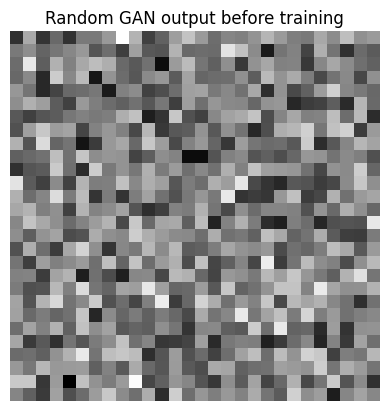

In [18]:
# Generate fake images:
import matplotlib.pyplot as plt

noise = torch.randn(1, 100)
gen = Generator()
fake_image = gen(noise).detach().view(28, 28)

print("Generated tensor shape:", fake_image.shape)
plt.imshow(fake_image, cmap="gray")
plt.title("Random GAN output before training")
plt.axis("off")
plt.show()

### Data Augmentation using GANs

**Concept Task:**

Fellows must:

- Generate synthetic samples
- Add to dataset
- Explain benefit

**Reflection questions:**

- Why use GAN augmentation?

- When is synthetic data risky?

## Section 6: Final Mini Project (Day 6–7)
🎯 **Build:** Text Analysis Tool


In [19]:
# Final Mini Project: Text Analysis Tool
from transformers import AutoTokenizer

project_tokenizer = AutoTokenizer.from_pretrained("gpt2")

def analyze_text(user_text):
    tokens = project_tokenizer.tokenize(user_text)
    token_count = len(tokens)
    summary_prompt = f"Summarize the following text in 2 clear bullet points:\n\n{user_text}"
    summary = gemini_generate(summary_prompt)
    return {
        "token_count": token_count,
        "tokens_preview": tokens[:20],
        "summary": summary,
    }

sample_text = "Generative AI can support students by explaining concepts, summarizing material, and helping with brainstorming, but it still needs human checking for accuracy."
analysis = analyze_text(sample_text)

print("Token count:", analysis["token_count"])
print("Token preview:", analysis["tokens_preview"])
print("Summary:\n", analysis["summary"])

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=91) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Gemini quota reached. Switching to local Hugging Face fallback.
Token count: 29
Token preview: ['Gener', 'ative', 'ĠAI', 'Ġcan', 'Ġsupport', 'Ġstudents', 'Ġby', 'Ġexplaining', 'Ġconcepts', ',', 'Ġsummar', 'izing', 'Ġmaterial', ',', 'Ġand', 'Ġhelping', 'Ġwith', 'Ġbrainstorm', 'ing', ',']
Summary:
 Summarize the following text in 2 clear bullet points:

Generative AI can support students by explaining concepts, summarizing material, and helping with brainstorming, but it still needs human checking for accuracy.
This article is about the AI system. For more information see this article.





The AI system is a system that uses a number of features, including:
Ability to learn and learn from each others.

Ability to interact with each other with other and with strangers.
Ability to learn and learn from each other's friends and family.
Ability to learn and learn from each other while they are in school.
Ability to learn from each other while they are in school.
Ability to learn and learn fr

In [20]:
# ⭐ Bonus (ALL FREE)
# Sentiment Analysis (Hugging Face)
classifier = pipeline("sentiment-analysis")

result = classifier("I love learning AI because it helps me build useful projects.")
print(f"Label: {result[0]['label']}, score: {result[0]['score']:.4f}")


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

c:\Users\Mishi\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mishi\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Label: POSITIVE, score: 0.9997


### Final Reflection

- I learned that LLMs are powerful for summarization, chat, prompting, and RAG, but they still depend heavily on prompt quality and context.
- The hardest part was choosing the right prompt and handling model or API setup issues.
- Gemini worked best for easy, high-quality responses, while Hugging Face was useful for free local experiments.
- Models failed when prompts were vague or when they had to answer without enough context.
- I would improve the notebook by adding stronger evaluation, more sample documents, and a cleaner user interface for the final project.


# 📊 Deliverables

Fellows submit:

 ✅ Notebook completed

 ✅ Tokenization outputs

 ✅ Summarization working

 ✅ Chatbot working

 ✅ Final project completed

 ✅ Short explanation (50-100 words)




---
                                                        ✴ THE END ✴
---

